# Stochastic Optimization Methods

This notebook introduces several optimization methods that deliberately use randomness.

Stochastic methods are useful when:

- the objective function has many local minima;
- deterministic descent methods get trapped too easily;
- gradients are noisy or unavailable;
- we want to explore a larger part of the search space.

We will study:

- **noisy descent**;
- **simulated annealing**;
- the **cross-entropy method**.

## Learning objectives

By the end of this notebook, you should be able to:

1. Explain why randomness can be useful in optimization.
2. Implement and interpret noisy gradient descent.
3. Explain the role of temperature in simulated annealing.
4. Compare different cooling schedules.
5. Explain the sampling-and-selection idea behind the cross-entropy method.
6. Investigate how stochastic algorithms depend on their parameters.
7. Compare stochastic methods using repeated runs rather than a single run.


In [2]:
using Logging

global_logger(ConsoleLogger(stderr, Logging.Info; show_limited=false))

ConsoleLogger(VSCodeServer.IJuliaCore.IJuliaStdio{Base.PipeEndpoint, typeof(VSCodeServer.io_send_callback)}(IOContext(Base.PipeEndpoint(RawFD(18) open, 0 bytes waiting)), VSCodeServer.io_send_callback), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (4524364368, 4524364400, 0)), Info, Base.CoreLogging.default_metafmt, false, 0, Dict{Any, Int64}())

In [3]:
using Plots, Distributions, LinearAlgebra
import Random: seed!

## 1. Noisy descent

A deterministic gradient-descent step has the form

$$
x_{k+1}=x_k-\alpha\nabla f(x_k),
$$

where $\alpha$ is the learning rate.

In **noisy descent**, a random perturbation is added to the deterministic step. A generic form is

$$
x_{k+1}
=
x_k-\alpha\nabla f(x_k)+\sigma_k\xi_k,
$$

where:

- $\xi_k$ is a random vector;
- $\sigma_k$ controls the magnitude of the noise;
- the noise may decrease as the number of iterations increases.

The purpose of the perturbation is to encourage exploration. Large noise allows larger random moves, while small noise makes the behavior increasingly similar to deterministic descent.


In [4]:
abstract type DescentMethod end

struct GradientDescent <: DescentMethod
    α
end

init!(M::GradientDescent, f, ∇f, x) = M

function step!(M::GradientDescent, f, ∇f, x)
    α, g = M.α, ∇f(x)
    return x - α * g

end

step! (generic function with 1 method)

In [5]:


mutable struct NoisyDescent <: DescentMethod
    submethod
    σ
    k
end

function init!(M::NoisyDescent, f, ∇f, x)
    init!(M.submethod, f, ∇f, x)
    M.k = 1
    return M
end

function step!(M::NoisyDescent, f, ∇f, x)
    x = step!(M.submethod, f, ∇f, x)
    σ = M.σ/M.k 
    x += σ .* randn(length(x))
    M.k += 1
    return x

end

step! (generic function with 2 methods)

In [6]:
f(x) = sum(x.^2)
∇f(x) = 2*x

∇f (generic function with 1 method)

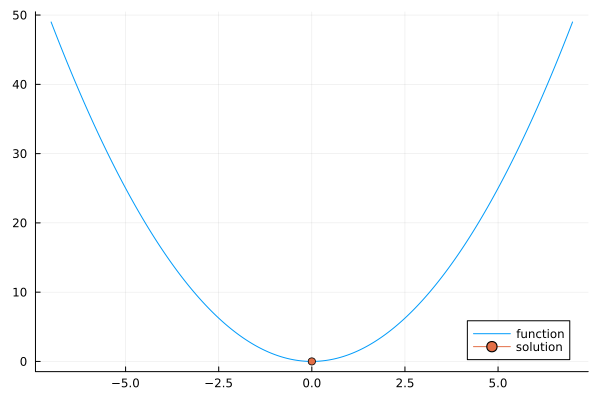

In [7]:
limits=range(-7,7,length=1000)
plot(limits, f.(limits), label="function")
plot!([0],[f(0)], mark=:circle, label="solution")

In [8]:
M=NoisyDescent(GradientDescent(0.1), 0.5,1)

NoisyDescent(GradientDescent(0.1), 0.5, 1)

In [9]:
M.k, M.σ

(1, 0.5)

0 [5.394386162396148] 0.605613837603852 2
1 [5.7588257166978] 0.36443955430165165 3
2 [5.602837798649822] 0.15598791804797774 4
3 [5.329447925711214] 0.2733898729386075 5
4 [5.0644908091764504] 0.26495711653476395 6
5 [4.823306372088533] 0.24118443708791748 7
6 [4.619597087272725] 0.2037092848158082 8
7 [4.495581144811959] 0.12401594246076542 9
8 [4.343030487001447] 0.15255065781051247 10
9 [4.216956381442402] 0.12607410555904508 11
10 [3.9793953739724146] 0.2375610074699872 12
11 [3.8266178216836453] 0.15277755228876932 13
12 [3.599728297812111] 0.2268895238715345 14
13 [3.439953384688923] 0.1597749131231878 15
14 [3.3256519489872596] 0.1143014357016634 16
15 [3.2210339138866324] 0.10461803510062717 17
16 [3.100089531320494] 0.12094438256613849 18
17 [2.901260761519944] 0.19882876980054975 19
18 [2.7616971650253617] 0.1395635964945825 20
19 [2.671193579214667] 0.09050358581069462 21
20 [2.5402975209045793] 0.13089605831008777 22
21 [2.4400499201091344] 0.10024760079544492 23
22 [2.354

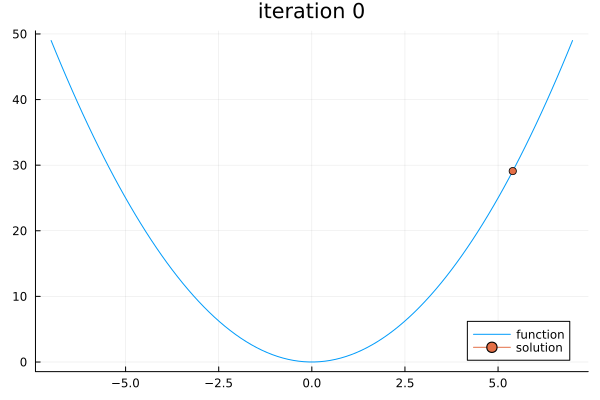

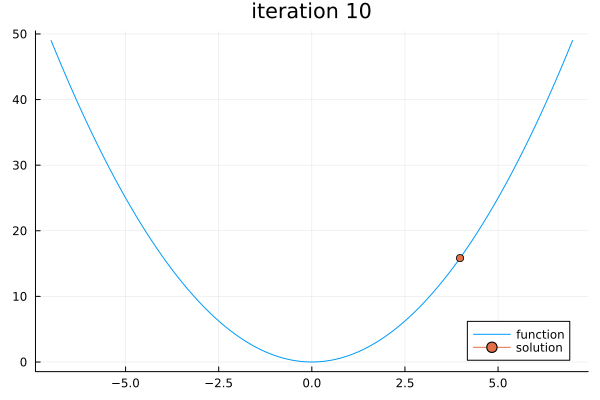

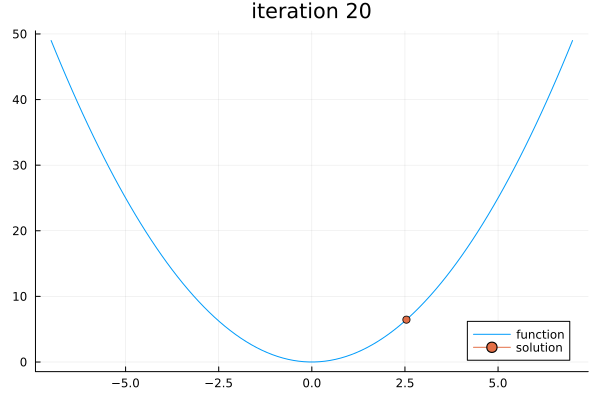

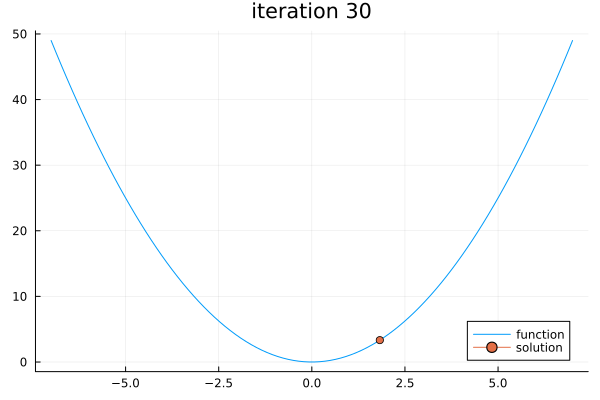

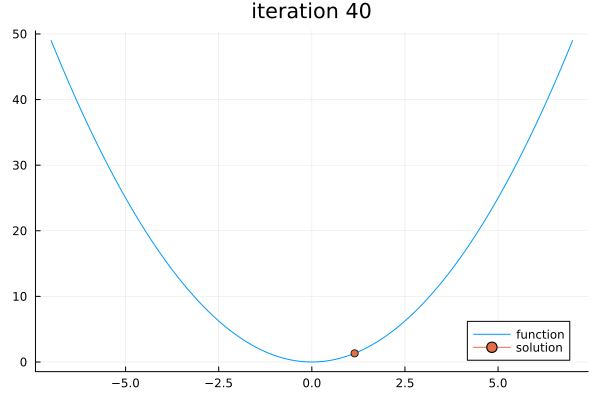

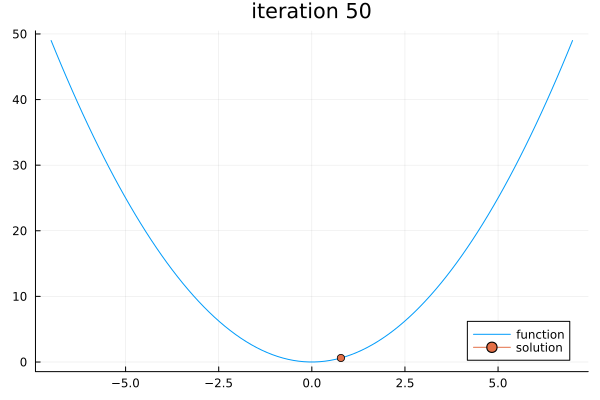

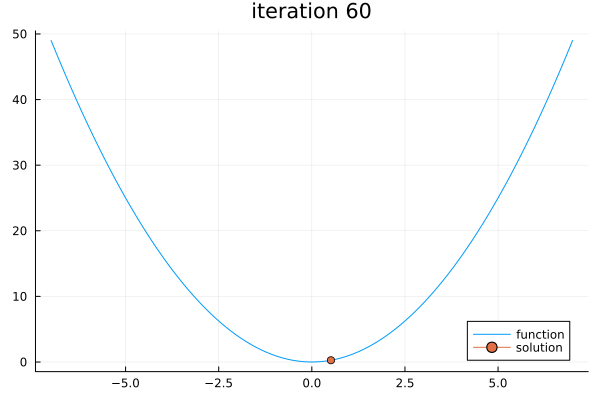

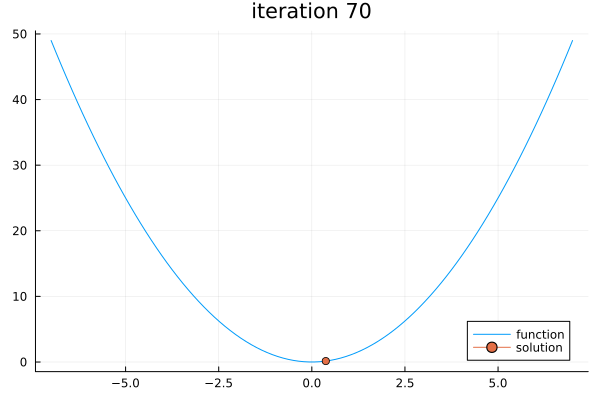

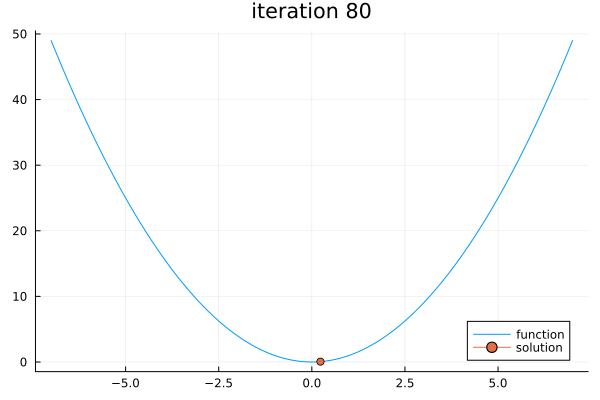

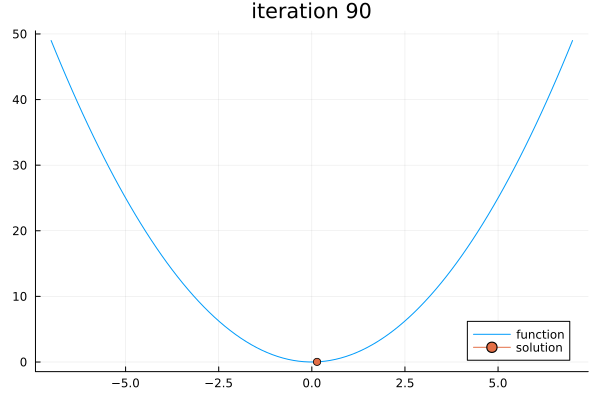

In [10]:
x = [6]
difference =1
M=NoisyDescent(GradientDescent(0.02), 0.5,1)
init!(M, f, ∇f, x)
iterations = 0
while (difference > 1e-6) & (iterations < 100)
    x_old=x
    x=step!(M, f, ∇f, x)
    difference=norm(x-x_old)
    println(iterations," ", x," ", difference, " ", M.k)
      
    if iterations % 10 == 0
        limits=range(-7,7,length=100)
        p=plot(limits, f.(limits), label="function")
        plot!(x,[f(x)], mark=:circle, label="solution")
        plot!(title="iteration $iterations")
        display(p)
    end
    iterations+=1 


end


### Exercise 1 — Deterministic versus noisy descent

Use

$$
f(x)=x^2
$$

with starting point $x_0=6$.

Compare:

1. ordinary gradient descent;
2. noisy descent.

Use the same learning rate for both methods.

Store the successive values of $x_k$ and plot them against the iteration number.

**Questions**

- Which trajectory is smoother?
- Does noisy descent always reduce the objective value at every step?
- As the noise decreases, what happens to the trajectory?


In [11]:
# Exercise 1

# Run deterministic gradient descent and noisy descent.
# Store the iterates and plot x_k versus iteration.


### Exercise 2 — Effect of the noise level

Run noisy descent with

$$
\sigma \in \{0.05,\;0.2,\;0.5,\;1.0\}.
$$

Use the same starting point and number of iterations.

For each value of $\sigma$:

1. plot the trajectory;
2. report the final solution;
3. report the final objective value.

**Discussion:** What is the trade-off between exploration and stability?


In [12]:
# Exercise 2

sigmas = [0.05, 0.2, 0.5, 1.0]

# Compare the different noise levels.


4-element Vector{Float64}:
 0.05
 0.2
 0.5
 1.0

### Exercise 3 — Why repeated runs matter

A stochastic algorithm can produce different results on different runs.

Run noisy descent **20 times** from the same starting point.

Store the final objective value from each run and compute:

- the mean;
- the standard deviation;
- the best value;
- the worst value.

Create a histogram of the final objective values.

**Question:** Why is reporting only one stochastic run potentially misleading?


In [13]:
# Exercise 3

n_runs = 20

# Run the method repeatedly and summarize the final objective values.


20

## 2. Simulated annealing

Simulated annealing is inspired by the physical process of slowly cooling a material.

At every iteration, the algorithm proposes a candidate solution $x'$.

If the candidate improves the objective, it is accepted.

If it is worse, it may still be accepted with a probability that depends on the increase in objective value and the current temperature.

For minimization, a common acceptance probability is

$$
p
=
\exp\left(
-\frac{f(x')-f(x)}{T}
\right).
$$

At high temperature, the algorithm is more willing to accept uphill moves. This promotes exploration.

As the temperature decreases, the algorithm becomes increasingly selective and behaves more like a local search method.


In [14]:
function ackley(x, a=20, b=0.2, c=2π)
    d = length(x)
    return -a*exp(-b*sqrt(sum(x.^2)/d)) -
              exp(sum(cos.(c*xi) for xi in x)/d) + a + ℯ
end

ackley (generic function with 4 methods)

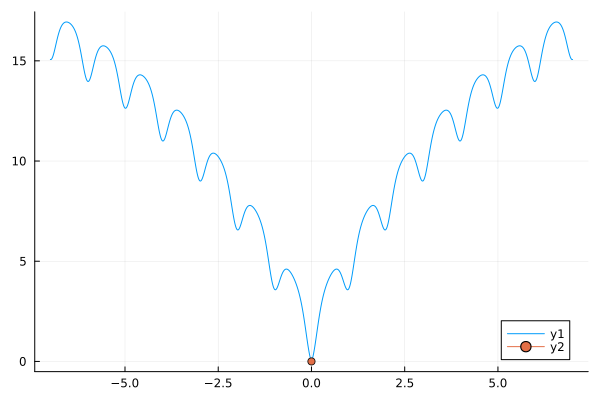

In [15]:
limits=range(-7,7,length=1000)
plot(limits, ackley.(limits))
plot!([0],[ackley(0)], mark=:circle)

In [16]:
function simulated_annealing(f, x, T, t_init, k_max)
    y = f(x)
    x_best, y_best = x, y
    t=t_init
    γ=0.5
    for k in 1 : k_max
        x′ = x + rand(T)
        y′ = f(x′)
        Δy = y′ - y
        if Δy ≤ 0 || rand() < exp(-Δy/t)
            x, y = x′, y′
        end
        if y′ < y_best
            x_best, y_best = x′, y′
        end
    # t=t/k #fast annealing
    t=γ*t # exponential annealing
    println(k, '\t', x_best,'\t', y_best, '\t', t,'\t', exp(-Δy/t)) 
    end
    return x_best, y_best
end

simulated_annealing (generic function with 1 method)

In [17]:
fobj = x-> ackley(x)
x=5
T=Normal()

Normal{Float64}(μ=0.0, σ=1.0)

In [18]:
simulated_annealing(fobj, x, T, 5, 100)

1	5	12.642411176571153	2.5	0.37930059954462975
2	5	12.642411176571153	1.25	0.38051780032660926
3	5	12.642411176571153	0.625	1.2180750293364202
4	5	12.642411176571153	0.3125	1.9097852247234968
5	3.859707946147667	11.587055528252423	0.15625	243041.15568402738
6	3.859707946147667	11.587055528252423	0.078125	1.5252086982380257e-12
7	3.859707946147667	11.587055528252423	0.0390625	8.076319633953445e-9
8	3.859707946147667	11.587055528252423	0.01953125	1.0331336465040225e-11
9	3.859707946147667	11.587055528252423	0.009765625	7.609852099741575e-103
10	3.859707946147667	11.587055528252423	0.0048828125	9.090694502031706e-242
11	3.859707946147667	11.587055528252423	0.00244140625	0.0
12	3.859707946147667	11.587055528252423	0.001220703125	0.0
13	2.6666095690787657	10.378881188098594	0.0006103515625	Inf
14	2.8608911671069923	9.532621650769368	0.00030517578125	Inf
15	1.931752319806721	6.644653797503466	0.000152587890625	Inf
16	1.931752319806721	6.644653797503466	7.62939453125e-5	0.0
17	1.9317523198067

(-0.03268551134585311, 0.186842209608042)

In [19]:
function simulated_annealing1(f, x, T, t_init, k_max)
    y = f(x)
    x_best, y_best = x, y
    t=t_init
    γ=0.5
    for k in 1 : k_max
        x′ = x + rand(T)
        y′ = f(x′)
        Δy = y′ - y
        if Δy ≤ 0 || rand() < exp(-Δy/t)
            x, y = x′, y′
        end
        if y′ < y_best
            x_best, y_best = x′, y′
            p=plot(limits, fobj.(limits), label ="f")
            plot!([x_best], [y_best], mark=:circle, label="current solution")
            plot!(title="iteration $k")
            display(p)
        end
    # t=t/k #fast annealing
    t=γ*t # exponential annealing
    println(k, '\t', x_best,'\t', y_best)
    
    # sleep(1)
    end
    return x_best
end

simulated_annealing1 (generic function with 1 method)

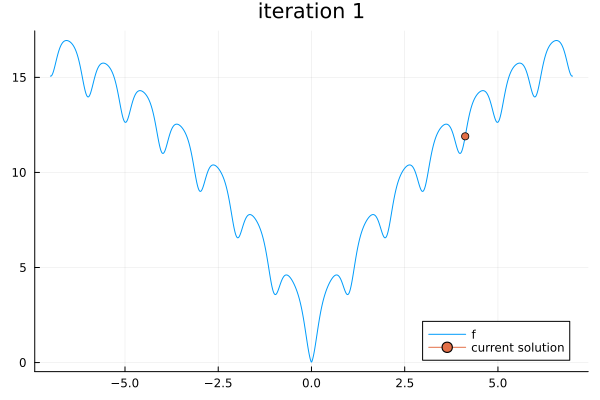

1	4.12256677424942	11.899326983585386
2	4.12256677424942	11.899326983585386
3	4.12256677424942	11.899326983585386
4	4.12256677424942	11.899326983585386
5	2.6289930628418197	10.394614337827218
6	2.6289930628418197	10.394614337827218
7	1.6657393475946938	7.781514551127913
8	1.8118528183715978	7.337082640487974
9	0.34559248311498236	3.4856899103123387
10	0.34559248311498236	3.4856899103123387
11	0.2789714335147062	2.969197553856049
12	0.2789714335147062	2.969197553856049
13	0.2789714335147062	2.969197553856049
14	0.2789714335147062	2.969197553856049
15	0.1874507843508794	1.9875711365046738
16	0.1874507843508794	1.9875711365046738
17	0.1874507843508794	1.9875711365046738
18	0.1874507843508794	1.9875711365046738
19	0.1874507843508794	1.9875711365046738
20	0.1874507843508794	1.9875711365046738
21	0.1874507843508794	1.9875711365046738
22	0.06680884818893623	0.49150020307561393
23	0.06680884818893623	0.49150020307561393
24	0.06680884818893623	0.49150020307561393
25	0.06680884818893623	0.491500

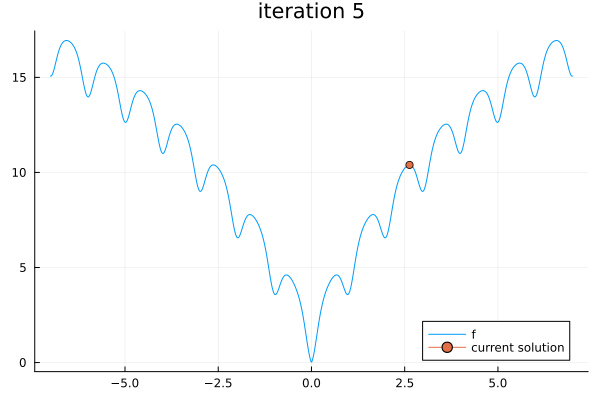

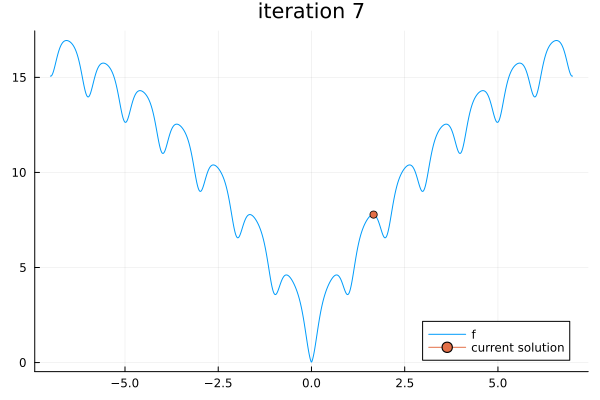

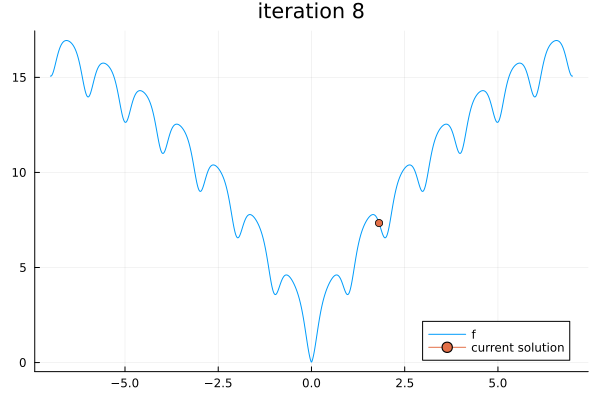

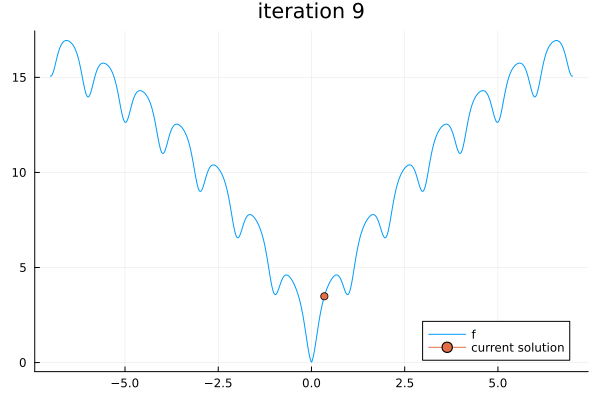

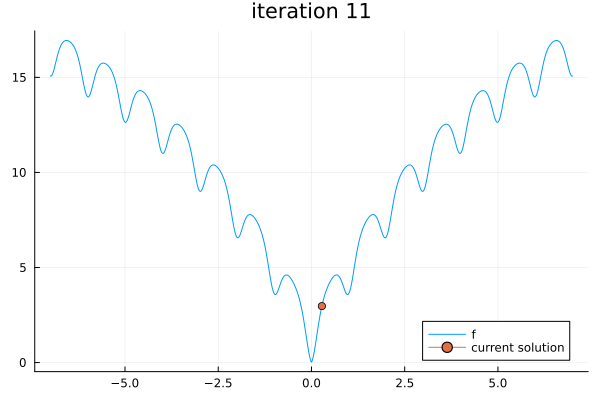

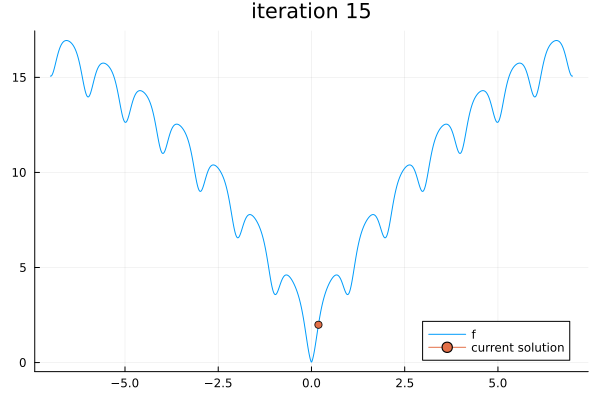

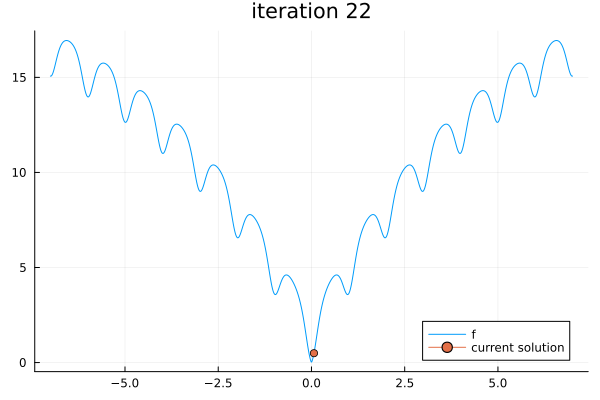

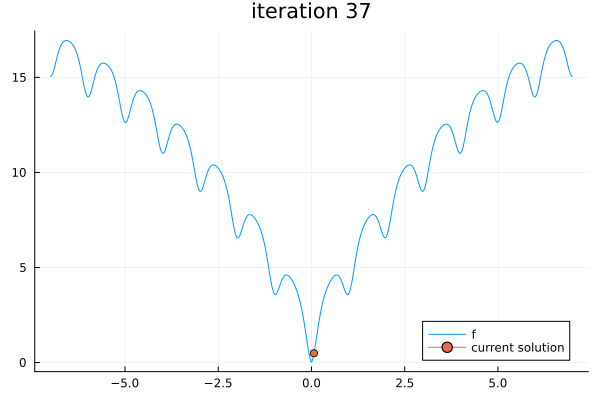

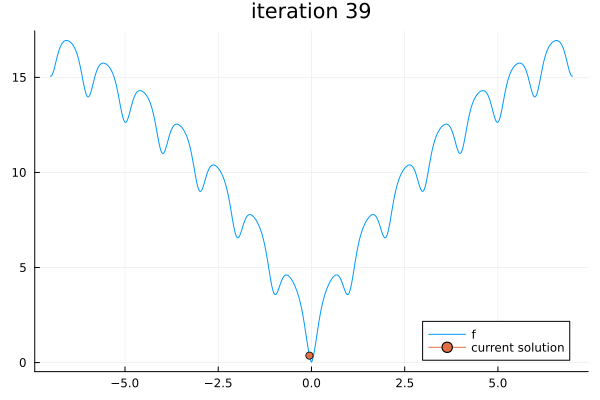

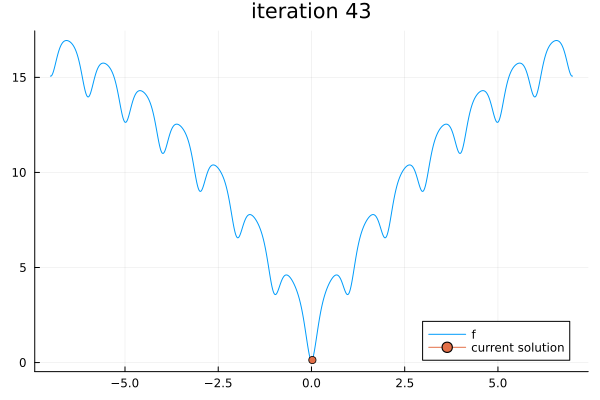

0.024810140899826055

In [20]:
simulated_annealing1(fobj, x, T, 5, 50)

### The Ackley function

The Ackley function is a standard test problem for global optimization.

In two dimensions it has many local structures but a known global minimum at

$$
x^\star=(0,0),
\qquad
f(x^\star)=0.
$$

It is therefore useful for illustrating why stochastic global-search methods can outperform purely local strategies.


### Exercise 4 — Explore the Ackley function

For the two-dimensional Ackley function:

1. create a contour plot on $[-5,5]\times[-5,5]$;
2. mark the global optimum;
3. choose three different starting points;
4. inspect the function values at those points.

**Question:** Why might a local descent method have difficulty on a multimodal function?


In [21]:
# Exercise 4

# Plot the two-dimensional Ackley function.
# Mark (0,0) and several starting points.


### Exercise 5 — Acceptance of worse solutions

Modify the simulated annealing code so that you count:

- how many improving moves are accepted;
- how many worsening moves are accepted;
- how many proposed moves are rejected.

Run the method once and print these counts.

**Question:** At which stage of the search do you expect most worsening moves to be accepted?


In [22]:
# Exercise 5

# Modify simulated_annealing to count the different types of moves.


### Exercise 6 — Compare cooling schedules

The **cooling schedule** determines how the temperature changes over time.

Compare at least three schedules, for example:

$$
T(k)=\frac{T_0}{k},
$$

$$
T(k)=\frac{T_0}{\log(k+1)},
$$

and

$$
T(k)=T_0\alpha^k,
\qquad 0<\alpha<1.
$$

Use the same starting point and iteration limit.

For each schedule:

1. store the best objective value found;
2. plot best-so-far objective value versus iteration;
3. repeat the experiment several times.

**Discussion:** What happens if the temperature decreases too rapidly?


In [23]:
# Exercise 6

# Define several cooling schedules and compare them.


### Exercise 7 — Initial temperature

Run simulated annealing with several initial temperatures, for example

$$
T_0\in\{0.1,\;1,\;5,\;20\}.
$$

Use the same cooling schedule and starting point.

For each temperature, perform at least 10 independent runs and compute the average final objective value.

**Question:** What happens when the initial temperature is too low? What about when it is very high?


In [24]:
# Exercise 7

initial_temperatures = [0.1, 1.0, 5.0, 20.0]

# Perform repeated runs for each initial temperature.


4-element Vector{Float64}:
  0.1
  1.0
  5.0
 20.0

## 3. The cross-entropy method

The cross-entropy method is a population-based stochastic optimization algorithm.

Instead of maintaining a single candidate solution, it maintains a **probability distribution** over possible solutions.

A typical iteration is:

1. sample $m$ candidate solutions from the current distribution;
2. evaluate all candidates;
3. select the best $m_{\text{elite}}$ candidates;
4. update the distribution parameters using only the elite samples;
5. repeat.

For a multivariate normal sampling distribution, the mean gradually moves toward promising regions, while the covariance usually decreases as the search concentrates.


In [25]:

function cross_entropy_method(f, P, k_max, m=100, m_elite=10)
    for k in 1:k_max
        samples = rand(P, m)
        order = sortperm([f(samples[:, i]) for i in 1:m])
        P = fit(typeof(P), samples[:, order[1:m_elite]])
        println(k, '\t', P.μ)
    end
    return P
end

cross_entropy_method (generic function with 3 methods)

In [26]:

seed!(0) # set random seed for reproducible results
f_ = x->norm(x)
μ = [0.5, 1.5]
Σ = [1.0 0.2; 0.2 2.0]
P = MvNormal(μ, Σ)
k_max = 10
P = cross_entropy_method(f_, P, k_max)
@show P.μ

1	[-0.015107219618417534, 0.2643593930986893]
2	[-0.05023723202329071, 0.0750315951549491]
3	[-6.70113718835054e-5, 0.013537636100998073]
4	[-0.0010185953781943393, 0.001687073399269524]
5	[0.00023746005911917615, 0.0013728418103874176]
6	[4.0851087658012074e-5, -8.167646213166626e-5]
7	[1.4858435798744828e-5, -1.983609827619567e-5]
8	[4.783644112336895e-6, -4.387652413179127e-6]
9	[-6.3353794565893e-6, 1.3884707457089107e-6]
10	[-1.7329565477016673e-6, -7.042440587115692e-7]
P.μ = [-1.7329565477016673e-6, -7.042440587115692e-7]


2-element Vector{Float64}:
 -1.7329565477016673e-6
 -7.042440587115692e-7

### Exercise 8 — Visualize the sampling distribution

Modify the cross-entropy implementation so that it stores the mean of the sampling distribution at every iteration.

For a two-dimensional objective:

1. plot the objective contours;
2. plot the sequence of distribution means;
3. optionally plot some of the sampled candidate points from selected iterations.

**Question:** How does the distribution move and concentrate during optimization?


In [28]:
# Exercise 8

# Modify cross_entropy_method so that it stores the distribution mean.
# Visualize the evolution of the sampling distribution.


### Exercise 9 — Elite sample size

The number of elite samples controls how strongly the algorithm focuses on the very best candidates.

Compare

$$
m_{\text{elite}}\in\{2,\;5,\;10,\;25,\;50\}
$$

for a fixed total sample size $m=100$.

For each value:

1. perform several independent runs;
2. record the best final objective value;
3. record the number of iterations;
4. inspect how quickly the sampling distribution collapses.

**Discussion:** What problems might occur if the elite set is too small?


In [29]:
# Exercise 9

elite_sizes = [2, 5, 10, 25, 50]

# Compare the different elite sample sizes.


5-element Vector{Int64}:
  2
  5
 10
 25
 50

### Exercise 10 — Sample size

Keep the elite fraction approximately constant and compare

$$
m\in\{20,\;50,\;100,\;500\}.
$$

For example, select the best 10% of each population.

For each sample size, compare:

- solution quality;
- variability between runs;
- number of function evaluations.

**Question:** Does increasing the sample size always make the method more efficient?


In [30]:
# Exercise 10

sample_sizes = [20, 50, 100, 500]

# Keep approximately 10% elite samples and compare the results.


4-element Vector{Int64}:
  20
  50
 100
 500

## 4. Comparing stochastic optimization methods

Stochastic algorithms should normally be compared over **multiple independent runs**.

Useful performance measures include:

- best objective value;
- mean final objective value;
- standard deviation;
- success rate;
- number of objective-function evaluations;
- convergence of the best-so-far solution.

A single run may be unusually good or unusually poor, so averages and variability are important.


### Exercise 11 — Mini benchmarking study

Choose a multimodal test function, such as Ackley.

Compare:

- noisy descent;
- simulated annealing;
- the cross-entropy method.

Use at least **20 independent runs** for each method.

Create a `DataFrame` containing:

- method;
- run;
- final objective value;
- best objective value;
- number of function evaluations.

Then compute grouped summary statistics.

Create at least one graphical comparison, for example:

- boxplots of final objective values;
- convergence curves;
- success rates.

Define a run as successful if the final objective value is below a small tolerance such as `1e-3`.


In [31]:
# Exercise 11

# using DataFrames

# Run each method multiple times and build a benchmarking table.


## 5. Reproducibility in stochastic optimization

Because these algorithms use random numbers, experiments should normally record the random seed.

For example:

```julia
using Random
Random.seed!(1234)
```

Using a fixed seed makes an experiment reproducible.

However, when evaluating the performance of a stochastic optimizer, it is better to use **multiple seeds** than to report only one.


### Exercise 12 — Reproducibility experiment

Run the same stochastic algorithm twice with

```julia
Random.seed!(123)
```

before each run.

Check whether the results are identical.

Then repeat using two different seeds.

**Questions**

1. Why is a fixed seed useful during debugging?
2. Why should algorithm comparisons use several seeds?


In [32]:
# Exercise 12

using Random

# Repeat the same experiment with identical and different seeds.


## Summary

In this notebook you studied three stochastic optimization ideas:

- **Noisy descent** combines deterministic descent with random perturbations.
- **Simulated annealing** occasionally accepts worse solutions, especially at high temperature.
- **Cross-entropy optimization** repeatedly samples a population and updates a probability distribution using elite solutions.

The most important difference from deterministic optimization is that the result itself is a random variable. Therefore, stochastic optimizers should usually be evaluated over repeated independent runs.

### Optional challenge

Choose a two-dimensional multimodal function and create a visual animation of one stochastic optimizer.

For example, show:

- the current solution;
- the best solution found so far;
- sampled candidates;
- or the evolution of the cross-entropy sampling distribution.

Use the animation to explain the balance between **exploration** and **exploitation**.


In [ ]:
# Optional challenge
